In [2]:
import os
SEED = 67
# Force GPU 1

# Clear GPU memory and restart clean
import torch
import gc
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device= torch.device("cpu")
print(device)
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    
import sys
from pathlib import Path

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd

import json
from datetime import datetime
from scipy import signal

torch.manual_seed(SEED)

cpu


In [3]:
from pngtojson import points_to_intensity_grid, png_to_xy_intensity, png_to_xy_binary

In [4]:
def load_data(folder_path):
    # Load the data from the specified folder
    data = dict()
    count = 0 
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.png'):
            #intensity_points = png_to_xy_intensity(os.path.join(folder_path, file_name),include_zero=True)
            intensity_points = png_to_xy_binary(os.path.join(folder_path, file_name),include_zero=True)
            intensity_grid = points_to_intensity_grid(intensity_points )
            intensity_df = pd.DataFrame(intensity_grid)
            data[file_name] = intensity_df
            count += 1
    print(f"Loaded {count} images.")
    
    return data

data = load_data("C:\\Users\\Jacobs laptop\\rainraingoaway\\data\\70km\\png")
print (len(data))

first_key, value = next(iter(data.items()))

print(f"ID {first_key}")
print(value.shape)
print(value.head())


In [5]:
#prev_key = first_key
def create_samples(data, list_length=10, min_list_length = 7):
    count = 1 
    data_grouped = list()
    sample_list= list()
    
    
    ttl_cnt = 0 
    keys = sorted(data.keys())
    prev_key = keys[0]

    for key in keys[1:]:
        value = data[key]
        value= torch.from_numpy(value.to_numpy()).float()
        ttl_cnt+=1
        key_time = datetime.strptime(str(key).strip(".png"),"%Y%m%d%H%M")
        prev_key_time = datetime.strptime(str(prev_key).strip(".png"),"%Y%m%d%H%M")
        change = key_time - prev_key_time
        change = int(change.seconds/60)
        #print(f"doing key {key}, with change {change}, cureent length is {len(sample_list)}, with count {count}")
        
    
        if change > 5: # if non continous jump, end sample
            data_grouped.append(sample_list)
            print(f"sample with lenth {len(sample_list)} created due to discontinuation in series, with change {change}")
            sample_list = list()
            sample_list.append(value)
            
            count=1
            
        elif change == 5 and count <list_length: # add value to sample if we arent at the limit
            sample_list.append(value)
            
            #print("appended")
            count += 1 
            
        elif change == 5 and count >= list_length: # shelve sample and start a new sample
            data_grouped.append(sample_list)
           # print(f"sample with lenth {len(sample_list)} created")
            sample_list = list()
            sample_list.append(value)
            
            count=1
        else:
            print("FUCCCKKK YOU FOING HERE" ) # should never reach this
        
        prev_key = key # pass on key information 
        
    #removing samples too short
    filtered=list()
    for idx, item in enumerate(data_grouped):
        length = len(item)

        if length < min_list_length:
            print(f"removed sample {idx} with length {length}")
        else:
            filtered.append(item)

    data_grouped = filtered
    x=list()
    y=list()

    for i in data_grouped:
        length= len(i)
        
        #print(length)
        last = i.pop(length-1)
        length= len(i)
        x.append(i)
        y.append(last)
        
    return x,y
            
            
#x,y = create_samples(data)

In [6]:
import os
import pandas as pd
from torch.utils.data import Dataset


class radar_dataset(Dataset):
    def __init__(self, folderloc , list_length=10, min_list_length = 10):
        min_list_length = list_length
        
        self.data = load_data(folderloc)
        self.x, self.y = create_samples(self.data,  list_length=list_length, min_list_length = min_list_length)
        
        
    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        sample = self.x[idx]
        target = self.y[idx]
        
        sample = torch.stack(sample).float()
        target = torch.tensor(target, dtype=torch.float32)
        return sample, target

In [7]:
sample_size= 4 
dataset= radar_dataset("C:\\Users\\Jacobs laptop\\rainraingoaway\\data\\70km\\png", list_length=sample_size)
split_idx = int(0.8 * len(dataset))


train_dataset = torch.utils.data.Subset(dataset, range(0, split_idx))
test_dataset = torch.utils.data.Subset(dataset, range(split_idx, len(dataset)))

Loaded 3420 images.
sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 15
sample with lenth 3 created due to discontinuation in series, with change 10
sample with lenth 2 created due to discontinuation in series, with change 10
sample with lenth 2 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 2 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 4 created due to discontinuation in series, with change 10
sample with lenth 2 created due to discontinuation in series, with change 10
sample with lenth 3 created due to discontinuation in se

C:\TEMP\ipykernel_25820\1229494528.py:14: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  value= torch.from_numpy(value.to_numpy()).float()


sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 4 created due to discontinuation in series, with change 10
sample with lenth 3 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 3 created due to discontinuation in series, with change 10
sample with lenth 2 created due to discontinuation in series, with change 10
sample with lenth 2 created due to discontinuation in series, with change 10
sample with lenth 3 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 2 created due to discontinuation in series, with change 10
sample with lenth 4 created due to discontinuation in series, with change 10

In [8]:
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Train batches :{len(train_loader)}")
print(f"Test batches :{len(test_loader)}")

Train samples: 666
Test samples: 167
Train batches :84
Test batches :21


In [9]:
def train_one_epoch(epoch_index, optimizer, model, loss_fn):
    running_loss = 0 
    last_loss = 0 
    for i , data in enumerate(train_loader):
        inputs, labels= data 
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        
        if labels.dim() == 3:
            labels = labels.unsqueeze(1)  # [batch, 120, 217] -> [batch, 1, 120, 217]
        loss = loss_fn(outputs, labels.float())
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        if i % 10 == 9:
            last_loss = running_loss / 10 # loss per batch
            print(f'  batch {i + 1} loss: {last_loss}')
            tb_x = epoch_index * len(train_loader) + i + 1
           
            running_loss = 0.
    return last_loss  

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [11]:
#import model
from mode import radar_cnn

model = radar_cnn(timesteps=(sample_size-1)).to(device)

In [12]:
#define loss function
import torch.optim
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
loss_fn = torch.nn.MSELoss().to(device)
loss_fn = torch.nn.SmoothL1Loss().to(device) # try image diff loss 
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([5.0]).to(device))

In [13]:


timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
#writer = SummaryWriter(f'runs/fashion_trainer_{timestamp}')
epoch_number = 0
val=[]
train=[]
EPOCHS = 2000

best_vloss = 1000000000000000


for epoch in range(EPOCHS):
    print(f'EPOCH {epoch_number + 1}:')

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_train_loss = train_one_epoch(epoch_number, optimizer,model,loss_fn)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(test_loader):
            vinputs, vlabels = vdata
            vinputs = vinputs.to(device)
            vlabels = vlabels.to(device)
            voutputs = model(vinputs)
            if vlabels.dim() == 3:
                vlabels = vlabels.unsqueeze(1)
            vloss = loss_fn(voutputs, vlabels.float())
            running_vloss += vloss

    avg_val_loss = running_vloss / (i + 1)
    print(f'LOSS train {avg_train_loss} valid {avg_val_loss}')
    val.append(avg_val_loss.item())
    train.append(avg_train_loss)

    # Log the running loss averaged per batch
    # for both training and validation


    # Track best performance, and save the model's state
    if avg_val_loss < best_vloss:
        best_vloss = avg_val_loss
        model_path = f'model_best.pkl'
        torch.save(model.state_dict(), model_path,)

    epoch_number += 1

EPOCH 1:


C:\TEMP\ipykernel_25820\1551617623.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(target, dtype=torch.float32)


  batch 10 loss: 0.8014707028865814
  batch 20 loss: 0.8237404346466064
  batch 30 loss: 0.8098648846149444
  batch 40 loss: 0.823760038614273
  batch 50 loss: 0.7943712949752808
  batch 60 loss: 0.8219443380832672
  batch 70 loss: 0.8195755422115326
  batch 80 loss: 0.794770348072052
LOSS train 0.794770348072052 valid 0.9885805249214172
EPOCH 2:


KeyboardInterrupt: 

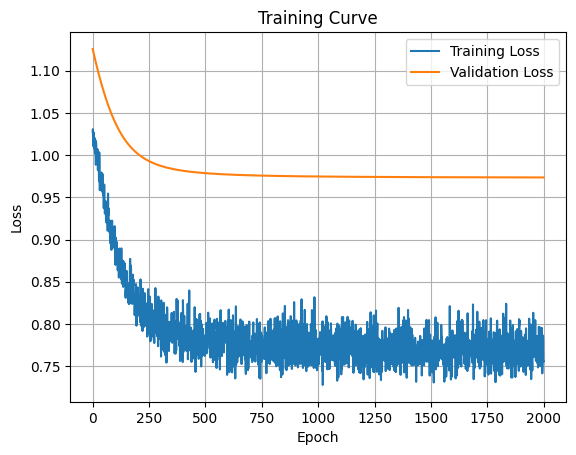

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train, label="Training Loss")
plt.plot(val, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Curve")
plt.legend()
plt.grid(True)
plt.show()

C:\TEMP\ipykernel_424\1551617623.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(target, dtype=torch.float32)


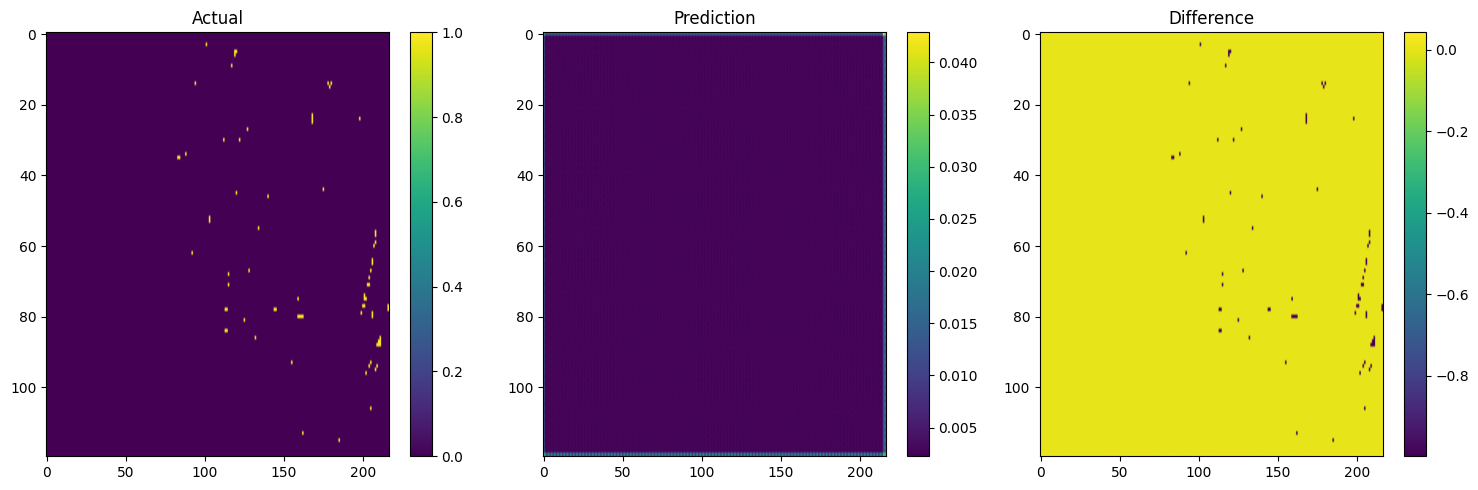

In [ ]:
import matplotlib.pyplot as plt
import torch

model.eval()

# get one batch
inputs, labels = next(iter(test_loader),4)

with torch.no_grad():
    outputs = model(inputs)
sample_no=6
# pick one sample from the batch
pred = outputs[sample_no]
actual = labels[sample_no]

# if shape is [1, H, W], remove the channel dimension
if pred.dim() == 3:
    pred = pred.squeeze(0)

if actual.dim() == 3:
    actual = actual.squeeze(0)

# move to cpu and convert to numpy
pred = pred.cpu().numpy()
actual = actual.cpu().numpy()

diff = pred - actual

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(actual, aspect='auto')
plt.title("Actual")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(pred, aspect='auto')
plt.title("Prediction")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(diff, aspect='auto')
plt.title("Difference")
plt.colorbar()

plt.tight_layout()
plt.show()

C:\TEMP\ipykernel_424\1551617623.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(target, dtype=torch.float32)


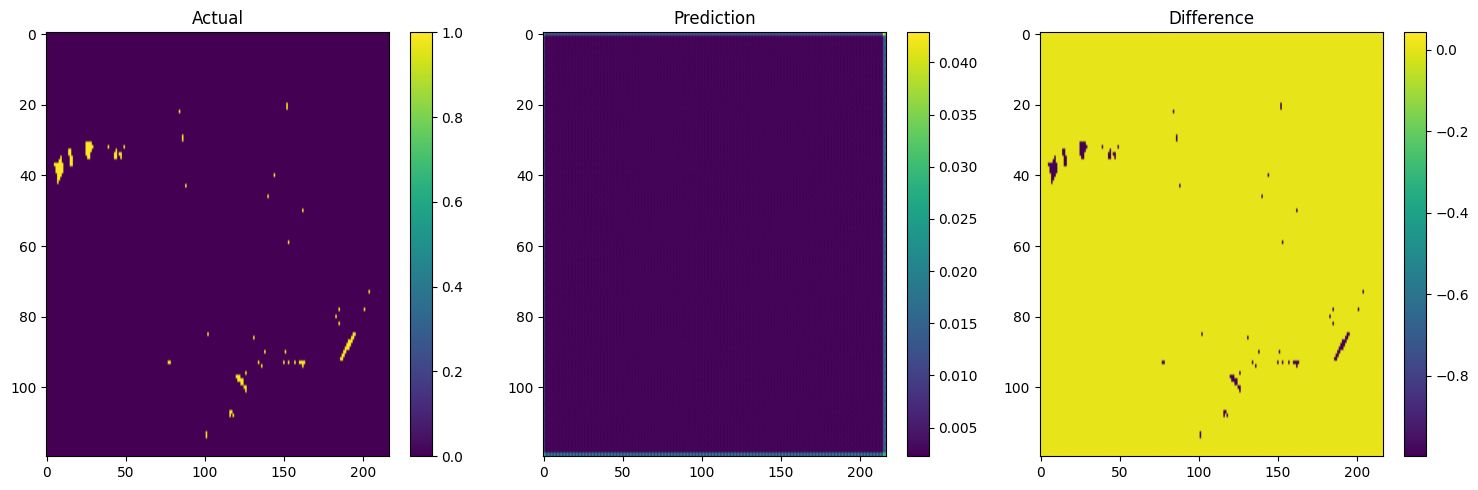

In [ ]:
import matplotlib.pyplot as plt
import torch

model.eval()

# get one batch
inputs, labels = next(iter(train_loader),3)

with torch.no_grad():
    outputs = model(inputs)
sample_no=6
# pick one sample from the batch
pred = outputs[sample_no]
actual = labels[sample_no]

# if shape is [1, H, W], remove the channel dimension
if pred.dim() == 3:
    pred = pred.squeeze(0)

if actual.dim() == 3:
    actual = actual.squeeze(0)

# move to cpu and convert to numpy
pred = pred.cpu().numpy()
actual = actual.cpu().numpy()

diff = pred - actual

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(actual, aspect='auto')
plt.title("Actual")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(pred, aspect='auto')
plt.title("Prediction")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(diff, aspect='auto')
plt.title("Difference")
plt.colorbar()

plt.tight_layout()
plt.show()